In [1]:
import json
import pandas as pd
import os
import requests
import numpy as np
import datetime

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd

In [2]:
api_key = "J6SHf5WXbL1NeF0EznTbatA9wknGGfzvp0Xeuk7U"

In [3]:
def get_api_url(weather_year, offset=0):
    return f"https://api.eia.gov/v2/electricity/rto/region-data/data/?frequency=hourly&data[0]=value&facets[respondent][]=CAL&start={weather_year}-01-01T00&end={weather_year + 1}-01-01T00&sort[0][column]=period&sort[0][direction]=desc&offset={offset}&length=5000&api_key={api_key}&facets[type][]=D"

hourly_demand_list = []

for weather_year in range(2023, 2024):
    print(f"Getting regional hourly demand for {weather_year}...")

    dfs = []
    num_responses = int(requests.get(get_api_url(weather_year)).json()['response']['total'])
    len_df = 0
    i = 0
    while len_df < num_responses:
        for _ in range(5):
            try:
                response = requests.get(get_api_url(weather_year, i*5000))
                response.raise_for_status()
                break
            except:
                print(f"Got status code {response.status_code}. Retrying API call.")
        
        df = pd.DataFrame.from_records(response.json()['response']['data'])
    
        i += 1
        len_df += len(df)
        dfs.append(df)
    
    hourly_demand = (
        pd.concat(dfs)
        .drop_duplicates()
        .sort_values("period")
        .reset_index(drop=True)
    )
    hourly_demand['timestamp'] = pd.to_datetime(hourly_demand['period'])
    hourly_demand_list.append(hourly_demand)

hourly_ca_demand = pd.concat(hourly_demand_list, ignore_index=True)

Getting regional hourly demand for 2023...


In [4]:
hourly_ca_demand = pd.concat(hourly_demand_list, ignore_index=True)
hourly_ca_demand = (
    hourly_ca_demand.loc[hourly_ca_demand.timestamp.dt.year == 2023]
    .copy()
)
hourly_ca_demand['value'] = pd.to_numeric(hourly_ca_demand['value'])
hourly_ca_demand = (
    hourly_ca_demand[['timestamp', 'value']]
    .set_index('timestamp')
    ['value']
)

In [5]:
retail_sales = pd.read_csv(
    '../data/county_ftm_sales_estimates.csv',
    index_col=['FIPS']
)
retail_sales.columns = [int(col) for col in retail_sales.columns]

direct_use = pd.read_csv('../data/county_direct_use.csv', index_col=['FIPS', 'is_pv'])
direct_use.columns = [int(col) for col in direct_use.columns]
direct_use = direct_use.groupby(direct_use.index.get_level_values('FIPS')).sum()

distpv_residential_consumption = pd.read_csv(
    '../data/county_distpv_residential_consumption.csv',
    index_col=['FIPS']
)
distpv_residential_consumption.columns = [int(col) for col in distpv_residential_consumption.columns]

distpv_non_residential_consumption = pd.read_csv(
    '../data/county_distpv_non_residential_consumption.csv',
    index_col=['FIPS']
)
distpv_non_residential_consumption.columns = [int(col) for col in distpv_non_residential_consumption.columns]

county_load_percentages = pd.read_csv(
    '../data/county_zone_load_percentage.csv',
    index_col=['FIPS', 'EIAcode']
)
county_load_percentages.columns = [int(col) for col in county_load_percentages.columns]

In [6]:
def get_baseline_load_profiles():
    baseline_load_profiles = {}
    hourly_demand_path = "../data/baseline_load_profiles/processed"
    for fname in os.listdir(hourly_demand_path):
        fpath = os.path.join(hourly_demand_path, fname)
        if os.path.isdir(fpath):
            continue
        df = pd.read_csv(fpath, parse_dates=["timestamp"], index_col="timestamp")
        eia_code = fname.replace('.csv', '')
        baseline_load_profiles[eia_code] = df['value']

    return baseline_load_profiles

In [7]:
import pandas as pd
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [8]:
def get_rooftop_pv_cf_meta():
    rooftop_pv_cf_meta = pd.read_csv("../data/distpv_profiles/county_centroid_project_points_conus.csv")
    rooftop_pv_cf_meta['FIPS'] = (
        'p' + rooftop_pv_cf_meta['GEOID'].astype(str).str.zfill(5)
    )
    rooftop_pv_cf_meta_geometry = [
        Point(xy) for xy in zip(rooftop_pv_cf_meta['longitude'], rooftop_pv_cf_meta['latitude'])
    ]
    rooftop_pv_cf_meta = gpd.GeoDataFrame(
        rooftop_pv_cf_meta,
        geometry=rooftop_pv_cf_meta_geometry,
        crs='EPSG:4326'
    )

    return rooftop_pv_cf_meta

def create_gid_county_map(rooftop_pv_cf_meta):
    ## Create mapping between counties and rooftop PV profile GIDs
    county_centroids = gpd.read_file("../data/shapefiles/US_COUNTY_2022")
    county_centroids['geometry'] = county_centroids['geometry'].centroid

    rooftop_pv_cf_meta_matched = rooftop_pv_cf_meta.loc[rooftop_pv_cf_meta.FIPS.isin(county_centroids.rb)]
    
    rooftop_pv_cf_meta_unmatched = rooftop_pv_cf_meta.loc[~rooftop_pv_cf_meta.FIPS.isin(county_centroids.rb)]
    county_centroids_unmatched = county_centroids.loc[~county_centroids.rb.isin(rooftop_pv_cf_meta_matched.FIPS)]
    rooftop_pv_cf_meta_unmatched = (
        gpd.sjoin_nearest(
            county_centroids_unmatched.drop(columns='FIPS').rename(columns={'rb': 'FIPS'})[['FIPS', 'geometry']],
            rooftop_pv_cf_meta_unmatched.drop(columns='FIPS').to_crs(county_centroids.crs),
            how='left'
        )
        .to_crs(rooftop_pv_cf_meta.crs)
        .drop(columns='index_right')
    )
    
    gid_county_map = (
        pd.concat([
            rooftop_pv_cf_meta_matched,
            rooftop_pv_cf_meta_unmatched
        ])
        .groupby('gid')
        ['FIPS']
        .apply(list)
        .explode()
    )

    return gid_county_map

def get_rooftop_pv_cf_profile(sector, gid_county_map):
    # Get rooftop PV CF profiles and normalize
    rooftop_pv_cf = pd.read_csv(f"../data/distpv_profiles/county_level_distpv_profiles_{sector}_2007_2023.csv")
    rooftop_pv_cf["datetime"] = pd.to_datetime(rooftop_pv_cf["Unnamed: 0"].str.split("\'").str[1])
    rooftop_pv_cf = rooftop_pv_cf.set_index("datetime").drop(columns=["Unnamed: 0"])
    rooftop_pv_cf = rooftop_pv_cf / rooftop_pv_cf.max().max()

    # Profiles only have 8760 hours, so leap years are missing the last day of the year
    # To fill in data for the last day, duplicate data from the second to last day
    for year in [2008, 2012, 2016, 2020]:
        df = (
            rooftop_pv_cf.loc[rooftop_pv_cf.index.year == year]
            .copy()
            .tail(24)
        )
        df = df.set_index(df.index.map(lambda x: x.replace(day=31)))
        rooftop_pv_cf = pd.concat([rooftop_pv_cf, df])
    
    rooftop_pv_cf = rooftop_pv_cf.sort_index()
    
    # Add county information
    rooftop_pv_cf.columns = rooftop_pv_cf_meta.gid
    rooftop_pv_cf = (
        rooftop_pv_cf.transpose()
        .merge(gid_county_map, left_index=True, right_index=True)
        .set_index('FIPS')
        .transpose()
    )
    
    rooftop_pv_cf.columns.name = ''
    rooftop_pv_cf.index.names = ['timestamp']
    rooftop_pv_cf.index = pd.to_datetime(rooftop_pv_cf.index)
    
    return rooftop_pv_cf

rooftop_pv_cf_meta = get_rooftop_pv_cf_meta()
gid_county_map = create_gid_county_map(rooftop_pv_cf_meta)

rooftop_pv_cf_profiles_by_sector = {}
for sector in ['residential', 'commercial']:
    rooftop_pv_cf_profiles_by_sector[sector] = get_rooftop_pv_cf_profile(sector, gid_county_map)

residential_profiles = rooftop_pv_cf_profiles_by_sector['residential']
non_residential_profiles = rooftop_pv_cf_profiles_by_sector['commercial']

In [9]:
def rescale_profile(profile, annual_totals):
    profile_norm = profile.apply(lambda x: x / x.groupby(x.index.year).transform('sum'))
    profile_norm = profile_norm.set_index(profile_norm.index.year, append=True)
    rescaled_profile = (
        profile_norm.mul(annual_totals.T, level=1)
        .fillna(0)
        .droplevel(1)
    )

    return rescaled_profile

In [10]:
baseline_load_profiles = get_baseline_load_profiles()

residential_distpv_profiles = rescale_profile(residential_profiles, distpv_residential_consumption)
residential_distpv_profiles = residential_distpv_profiles.loc[residential_distpv_profiles.index.year == 2023].copy()

non_residential_distpv_profiles = rescale_profile(non_residential_profiles, distpv_non_residential_consumption)
non_residential_distpv_profiles = non_residential_distpv_profiles.loc[non_residential_distpv_profiles.index.year == 2023].copy()

In [11]:
zone_load_profiles = pd.concat(
    {k:v.loc[v.index.year == 2023] for k,v in baseline_load_profiles.items()},
    axis=1
)

In [12]:
rsdu = retail_sales.add(direct_use, fill_value=0)
for year in range(2023, 2024):
    rsdu = rsdu.merge(
        county_load_percentages[[year]].rename(columns={year: 'weight'}),
        left_index=True,
        right_index=True
    )
    rsdu[year] *= rsdu['weight']
    rsdu = rsdu.drop(columns='weight')

rsdu_profiles_by_county = {}
for county in rsdu.index.get_level_values('FIPS').unique():
    county_rsdu_by_zone = rsdu.loc[county]
    zones = list(county_rsdu_by_zone.index)
    county_zone_load_profiles = zone_load_profiles[zones].copy()
    county_rsdu_profile = rescale_profile(
        county_zone_load_profiles, county_rsdu_by_zone
    )
    rsdu_profiles_by_county[county] = county_rsdu_profile.sum(axis=1)

county_rsdu_profiles = pd.concat(rsdu_profiles_by_county, axis=1)

In [13]:
county_rsdu_distpv_profiles = (
    county_rsdu_profiles.add(residential_distpv_profiles.tz_localize(None))
    .add(non_residential_distpv_profiles.tz_localize(None))
)

In [14]:
import sys
sys.path.append('..')

from helpers import get_county2zone
county2zone = get_county2zone(2023)
ca_counties = county2zone.loc[county2zone.state == 'CA']['FIPS'].tolist()

In [15]:
observed_zonal_profile_rsdu = (
    county_rsdu_profiles[ca_counties]
    .sum(axis=1)
)
observed_zonal_profile = (
    county_rsdu_distpv_profiles[ca_counties]
    .sum(axis=1)
)

In [16]:
def plot_everything(df1, df2, title1, title2, agglabel):
    f, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    
    df1.loc[df1.index.year == 2023].plot(
        ax=ax[0],
        alpha=0.5,
        color='blue',
    )
    df2.loc[df2.index.year == 2023].plot(
        ax=ax[0],
        alpha=0.5,
        color='red',
        title=title1,
        xlabel='Time (UTC)',
        ylabel='Load (MW)'
    )

    ax[0].set_title(f'(a)\n\n{title1}', fontweight='bold')

    start_point = df1.loc[df1.index.year == 2023].idxmax() - pd.Timedelta(days=3.5)
    end_point = df1.loc[df1.index.year == 2023].idxmax() + pd.Timedelta(days=3.5)
    df1.loc[(df1.index >= start_point) & (df1.index <= end_point)].plot(
        ax=ax[1],
        color='blue',
        label='Supply-derived load (EIA-930)',
        legend=True,
    )
    df2.loc[(df2.index >= start_point) & (df2.index <= end_point)].plot(
        ax=ax[1],
        color='red',
        title=title2,
        label=agglabel,
        legend=True,
        xlabel='Time (UTC)',
    )

    ax[1].set_title(f'(b)\n\n{title2}', fontweight='bold')

    plt.legend(loc='lower center', bbox_to_anchor=(-0.15, -0.4))

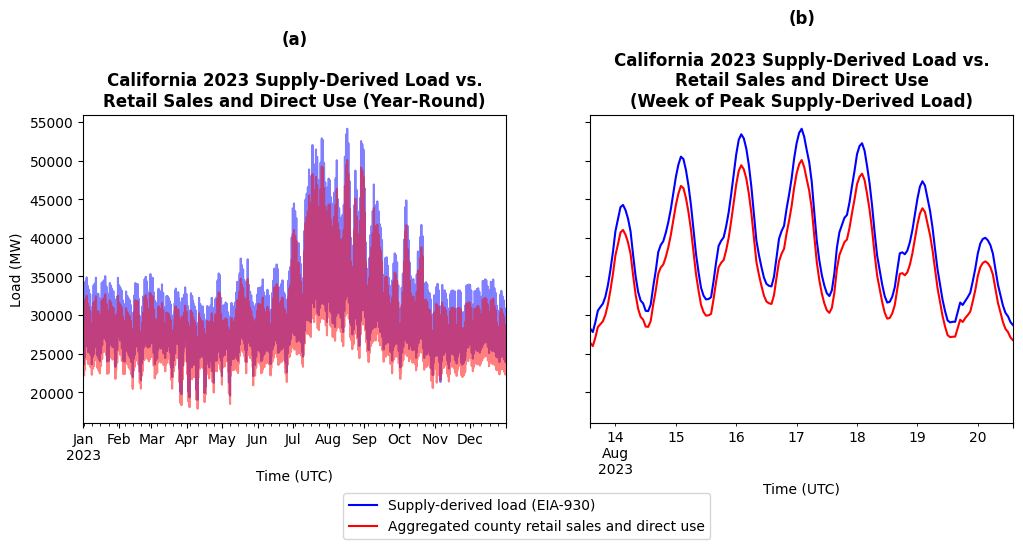

In [17]:
plot_everything(
    hourly_ca_demand,
    observed_zonal_profile_rsdu,
    'California 2023 Supply-Derived Load vs.\nRetail Sales and Direct Use (Year-Round)',
    'California 2023 Supply-Derived Load vs.\nRetail Sales and Direct Use\n(Week of Peak Supply-Derived Load)',
    'Aggregated county retail sales and direct use'
)
plt.show()
# plt.savefig('ca_load_vs_rsdu.png', dpi=300, bbox_inches='tight')

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
X = np.array(hourly_ca_demand).reshape(-1, 1)
y = np.array(observed_zonal_profile_rsdu)
reg = LinearRegression().fit(X, y)
reg.score(X, y)

0.9970268268579832

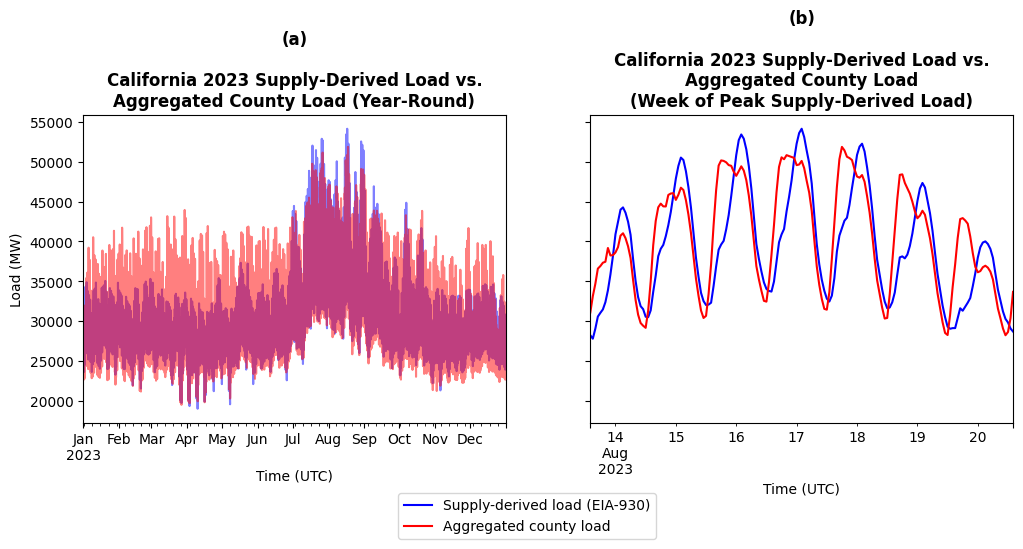

In [20]:
plot_everything(
    hourly_ca_demand,
    observed_zonal_profile,
    'California 2023 Supply-Derived Load vs.\nAggregated County Load (Year-Round)',
    'California 2023 Supply-Derived Load vs.\nAggregated County Load\n(Week of Peak Supply-Derived Load)',
    'Aggregated county load'
)
plt.show()
# plt.savefig('ca_load_vs_agg_county_load.png', dpi=300, bbox_inches='tight')

In [21]:
X = np.array(hourly_ca_demand).reshape(-1, 1)
y = np.array(observed_zonal_profile)
reg = LinearRegression().fit(X, y)
reg.score(X, y)

0.5429256208659645